<a id="sec-title"></a>

# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** Sijie Yang, Zdravko Trivic, Yihan Zhu, Mahmoud Abdelrahman, Filip Biljecki*

by Urban Analytics Lab, National University of Singapore

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).


<a id="sec-overview"></a>

## Data: Social Media Post Embedding Processing

This notebook combines (1) **post-level image embeddings**, ablation for different embedding methods, clustering, and map-linked visualisation; (2) **post-level caption embeddings** for comfort-level assessment for each post with sentence transformer; (3) **§5** merges comfort into the activity GPKG, builds `social_activity_comfort_*` fields, and plots three-panel maps per activity.


Primary handover fields:
- post-level image embedding by different methods: ***SigLIP2*** variants, ***ResNet***, and ***ViT***.
- post-level text embedding by ***Sentence Transformer*** `all-MiniLM-L6-v2`.


Unless stated otherwise, **all code inputs and outputs** use the folder `data_post_embedding/` (`P = Path('data_post_embedding')` in cells).

Data source used in this notebook:
- post-level image embedding:
    - `data_post_embedding/dataset_post_siglip2_image_only_features.npy`
    - `data_post_embedding/dataset_post_siglip2_equal_features.npy`
    - `data_post_embedding/dataset_post_siglip2_gated_features.npy`
    - `data_post_embedding/dataset_post_resnet_features.npy`
    - `data_post_embedding/dataset_post_vit_features.npy`
- post embedding row alignment to grid `id`: `data_post_embedding/dataset_post_embedding_grid_id.npy`.
- clustering results for each post: `data_post_embedding/embedding_index_grid_cluster.csv`
- activity label for clustering results (human label): `data_post_embedding/cluster_activity_config.json`.
- post-level caption analytics (§4): requires ST + `has_text` `.npy` under `data_post_embedding/`; **§4.1** → `data_post_embedding/dataset_post_comfort_*.npy`; **§4.2** adds **activity** from clustering + config; **§4.4** writes `avg_comfort_score` and `avg_comfort_{eating,...}` per grid (and refreshes GPKG).
- geospatial grid data: `data_post_embedding/grid_point_coordinates.csv`.

Output:
- geopackage file for social activity intensity: `data_post_embedding/data_social_activity.gpkg`.
- caption comfort table: `data_post_embedding/caption_analytics_results.csv`.
- **§5** adds `social_activity_comfort_*` to the GPKG, refreshes `data_post_embedding/data_social_activity.gpkg`, and plots activity | comfort | product maps.

Section list in this notebook file:

- [Title & license](#sec-title)
- [Data overview](#sec-overview)
- [1. Ablation for different post representations](#sec-1-ablation)
- [2. K-means Clustering over Resnet Representation](#sec-2-kmeans)
- [3. Do Visualization based on Categorization Result](#sec-3-viz)
- [4. Caption analytics for comfort level evaluation](#sec-4-caption)
- [4.1 Comfort scores from post-level caption embeddings](#sec-4-1-comfort)
- [4.2 Integrate comfort scores for each post with its activity types](#sec-4-2-integrate)
- [4.3 Overall score summary and visualisation](#sec-4-3-summary)
- [4.4 Merge comfort into grid point and geopackage file](#sec-4-4-merge)
- [5. Result visualisation](#sec-5-result-viz)



<a id="sec-1-ablation"></a>

## 1. Ablation for different post representations

Compares ***SigLIP2*** (`siglip2_image`, `siglip2_fusion_*`) plus ***ResNet*** and ***ViT*** on the same aligned rows (no separate text-only row).  

| Variant key (`variants`) | Encoder | Typical dim | Source |
| --- | --- | --- | --- |
| `siglip2_image` | SigLIP2 image tower, L2 | 768 | `data_post_embedding/dataset_post_siglip2_image_only_features.npy` |
| `siglip2_fusion_equal` | SigLIP2 equal fusion | 768 | `data_post_embedding/dataset_post_siglip2_equal_features.npy` |
| `siglip2_fusion_gated` | SigLIP2 gated fusion | 768 | `data_post_embedding/dataset_post_siglip2_gated_features.npy` |
| `resnet` | ResNet-50 pool | 2048 | `data_post_embedding/dataset_post_resnet_features.npy` |
| `vit` | ViT-B/16 (ImageNet) | 768 | `data_post_embedding/dataset_post_vit_features.npy` |

The next two cells load these arrays (aligned row count), then ***KMeans*** with ***silhouette + DB + CH + inertia*** (mean/std over seeds).  
Default downstream features is set to ***Resnet*** after load (change one line if you pick another winner).


In [17]:
# Load embeddings for ablation (SigLIP2 image/fusions + ResNet + ViT)
# Per-row grid id (same length as features) — aligns each embedding with `id` in grid_point_coordinates.csv
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA

POST_EMBED_DIR = Path('data_post_embedding')
POST_EMBED_DIR.mkdir(parents=True, exist_ok=True)
P = POST_EMBED_DIR

GRID_NPY = P / 'dataset_post_embedding_grid_id.npy'

features_siglip2_image = np.load(P / 'dataset_post_siglip2_image_only_features.npy')
features_siglip2_fusion_equal = np.load(P / 'dataset_post_siglip2_equal_features.npy')
features_siglip2_fusion_gated = np.load(P / 'dataset_post_siglip2_gated_features.npy')
features_resnet = np.load(P / 'dataset_post_resnet_features.npy')
features_vit = np.load(P / 'dataset_post_vit_features.npy')

n_align = min(
    len(features_siglip2_image),
    len(features_siglip2_fusion_equal),
    len(features_siglip2_fusion_gated),
    len(features_resnet),
    len(features_vit),
)

if GRID_NPY.exists():
    embedding_grid_id = np.load(GRID_NPY).astype(np.int64).reshape(-1)
    if len(embedding_grid_id) < n_align:
        raise ValueError(f'{GRID_NPY} length {len(embedding_grid_id)} < feature rows {n_align}')
    embedding_grid_id = embedding_grid_id[:n_align]
else:
    raise FileNotFoundError(
        f'Missing {GRID_NPY} (length must match embeddings). '
        f'Run the next OPTIONAL cell once if you still have dataset_post_siglip2_image_paths.npy '
        f'to build grid ids from paths like .../photos_2/<grid_id>/...; otherwise create the array yourself.'
    )

features_siglip2_image = features_siglip2_image[:n_align].astype(np.float32)
features_siglip2_fusion_equal = features_siglip2_fusion_equal[:n_align].astype(np.float32)
features_siglip2_fusion_gated = features_siglip2_fusion_gated[:n_align].astype(np.float32)
features_resnet = features_resnet[:n_align].astype(np.float32)
features_vit = features_vit[:n_align].astype(np.float32)

# variance_target: float in (0,1) = keep components until cumulative variance >= target
def _pca_transform(X, name, random_state=42, variance_target=0.85, max_components=None):
    n_rank = max(1, X.shape[0] - 1)
    n_feat = X.shape[1]
    if max_components is not None:
        n_comp = min(int(max_components), n_rank, n_feat)
        pca = PCA(n_components=n_comp, random_state=random_state)
    else:
        pca = PCA(n_components=variance_target, random_state=random_state)
    Z = pca.fit_transform(X.astype(np.float64)).astype(np.float32)
    print(f'  {name}: {X.shape[1]}D -> {Z.shape[1]}D, var explained={pca.explained_variance_ratio_.sum():.4f}')
    return Z

print('Aligned rows:', n_align)
print('Grid id array:', embedding_grid_id.shape, 'valid (>=0):', int(np.sum(embedding_grid_id >= 0)))
print('PCA per variant (retain 85% variance by default; set max_components=512 to cap dims):')
features_siglip2_image = _pca_transform(features_siglip2_image, 'siglip2_image')
features_siglip2_fusion_equal = _pca_transform(features_siglip2_fusion_equal, 'siglip2_fusion_equal')
features_siglip2_fusion_gated = _pca_transform(features_siglip2_fusion_gated, 'siglip2_fusion_gated')
features_resnet = _pca_transform(features_resnet, 'resnet')
features_vit = _pca_transform(features_vit, 'vit')

# Default embedding for downstream (change if another variant wins ablation)
features = features_resnet
features_pca = features


Aligned rows: 44228
Grid id array: (44228,) valid (>=0): 44228
PCA per variant (retain 85% variance by default; set max_components=512 to cap dims):
  siglip2_image: 768D -> 253D, var explained=0.8502
  siglip2_fusion_equal: 768D -> 289D, var explained=0.8505
  siglip2_fusion_gated: 768D -> 254D, var explained=0.8503
  resnet: 2048D -> 156D, var explained=0.8502
  vit: 768D -> 370D, var explained=0.8506


In [3]:
# Compare all rows in the Ablation table with multi-metric + multi-seed stats
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans
import pandas as pd
from tqdm import tqdm
import numpy as np

n_clusters_eval = 8
rng = np.random.RandomState(42)
seeds_eval = [0, 1, 2, 3, 4]

variants = {
    'siglip2_image': features_siglip2_image,
    'siglip2_fusion_equal': features_siglip2_fusion_equal,
    'siglip2_fusion_gated': features_siglip2_fusion_gated,
    'resnet': features_resnet,
    'vit': features_vit,
}

n_total = min(len(emb) for emb in variants.values())
sample_n = min(n_total, 10000)
idx = rng.choice(n_total, size=sample_n, replace=False) if n_total > sample_n else np.arange(n_total)
print(f'Ablation sample: {sample_n} / {n_total} rows (aligned across variants)')
print(f'Metrics over {len(seeds_eval)} seeds: {seeds_eval}')

rows = []
for name, emb in tqdm(variants.items(), desc='Ablation variants'):
    emb_s = emb[idx]

    sil_list, db_list, ch_list, inertia_list = [], [], [], []
    for sd in seeds_eval:
        km = KMeans(n_clusters=n_clusters_eval, n_init=10, random_state=sd)
        labels = km.fit_predict(emb_s)

        sil = silhouette_score(
            emb_s,
            labels,
            sample_size=min(5000, len(emb_s)) if len(emb_s) > 5000 else None,
            random_state=sd,
        )
        db = davies_bouldin_score(emb_s, labels)
        ch = calinski_harabasz_score(emb_s, labels)

        sil_list.append(float(sil))
        db_list.append(float(db))
        ch_list.append(float(ch))
        inertia_list.append(float(km.inertia_))

    rows.append({
        'variant': name,
        'silhouette_mean': float(np.mean(sil_list)),
        'silhouette_std': float(np.std(sil_list)),
        'db_mean': float(np.mean(db_list)),
        'db_std': float(np.std(db_list)),
        'ch_mean': float(np.mean(ch_list)),
        'ch_std': float(np.std(ch_list)),
        'inertia_mean': float(np.mean(inertia_list)),
        'inertia_std': float(np.std(inertia_list)),
    })

comparison_df = pd.DataFrame(rows).sort_values('silhouette_mean', ascending=False)
print(comparison_df)
print('Ablation complete.')


Ablation sample: 10000 / 44228 rows (aligned across variants)
Metrics over 5 seeds: [0, 1, 2, 3, 4]


Ablation variants: 100%|██████████| 5/5 [00:27<00:00,  5.43s/it]

                variant  silhouette_mean  silhouette_std   db_mean    db_std  \
3                resnet         0.054830        0.000732  3.623524  0.001202   
0         siglip2_image         0.044753        0.001734  3.951533  0.039122   
2  siglip2_fusion_gated         0.044158        0.002202  3.963393  0.019093   
4                   vit         0.028705        0.000653  4.908750  0.009976   
1  siglip2_fusion_equal         0.026676        0.001321  4.280320  0.092392   

      ch_mean    ch_std  inertia_mean  inertia_std  
3  321.576398  0.003934  2.422685e+06     5.299528  
0  258.678986  1.409727  3.483000e+03     2.915478  
2  259.933472  0.187201  3.451621e+03     0.382763  
4  161.844955  0.010975  2.694607e+06    18.763395  
1  225.793216  0.676371  2.473688e+03     1.012346  
Ablation complete.


<a id="sec-2-kmeans"></a>

## 2. K-means Clustering over Resnet Representation


In [4]:
# compute k-sweep metrics table
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from tqdm import tqdm
import numpy as np
import pandas as pd

# features_pca: PCA-reduced in load cell (same as default `features`)
X = np.asarray(features_pca)

k_min, k_max = 2, 20
k_range = list(range(k_min, k_max))
seeds = [0, 1, 2, 3, 4]
sample_size = min(10000, len(X)) if len(X) > 10000 else None

rows = []

for k in tqdm(k_range, desc='KMeans multi-metric k sweep'):
    inertia_list, sil_list, ch_list, db_list = [], [], [], []
    labels_list = []
    size_cv_list, min_frac_list = [], []

    for s in seeds:
        km = KMeans(n_clusters=k, random_state=s, n_init=10)
        labels = km.fit_predict(X)
        cnt = np.bincount(labels, minlength=k).astype(float)

        inertia_list.append(km.inertia_)
        sil_list.append(silhouette_score(X, labels, sample_size=sample_size, random_state=s))
        ch_list.append(calinski_harabasz_score(X, labels))
        db_list.append(davies_bouldin_score(X, labels))
        labels_list.append(labels)
        size_cv_list.append(float(cnt.std() / (cnt.mean() + 1e-12)))
        min_frac_list.append(float(cnt.min() / cnt.sum()))

    ari_vals = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            ari_vals.append(adjusted_rand_score(labels_list[i], labels_list[j]))

    rows.append({
        'k': k,
        'inertia_mean': float(np.mean(inertia_list)),
        'inertia_std': float(np.std(inertia_list)),
        'silhouette_mean': float(np.mean(sil_list)),
        'silhouette_std': float(np.std(sil_list)),
        'calinski_harabasz_mean': float(np.mean(ch_list)),
        'davies_bouldin_mean': float(np.mean(db_list)),
        'seed_stability_ari_mean': float(np.mean(ari_vals)),
        'size_cv_mean': float(np.mean(size_cv_list)),
        'min_cluster_frac_mean': float(np.mean(min_frac_list)),
    })

k_eval_df = pd.DataFrame(rows)

for c in [
    'silhouette_mean',
    'calinski_harabasz_mean',
    'seed_stability_ari_mean',
    'min_cluster_frac_mean',
    'davies_bouldin_mean',
    'size_cv_mean',
]:
    mu, sd = k_eval_df[c].mean(), k_eval_df[c].std() + 1e-12
    k_eval_df[c + '_z'] = (k_eval_df[c] - mu) / sd

k_eval_df['composite_score'] = (
    + 0.30 * k_eval_df['silhouette_mean_z']
    + 0.20 * k_eval_df['calinski_harabasz_mean_z']
    + 0.20 * k_eval_df['seed_stability_ari_mean_z']
    + 0.10 * k_eval_df['min_cluster_frac_mean_z']
    - 0.10 * k_eval_df['davies_bouldin_mean_z']
    - 0.10 * k_eval_df['size_cv_mean_z']
)

print('k_eval_df is ready for plotting and diagnosis.')

KMeans multi-metric k sweep: 100%|██████████| 18/18 [04:12<00:00, 14.04s/it]

k_eval_df is ready for plotting and diagnosis.


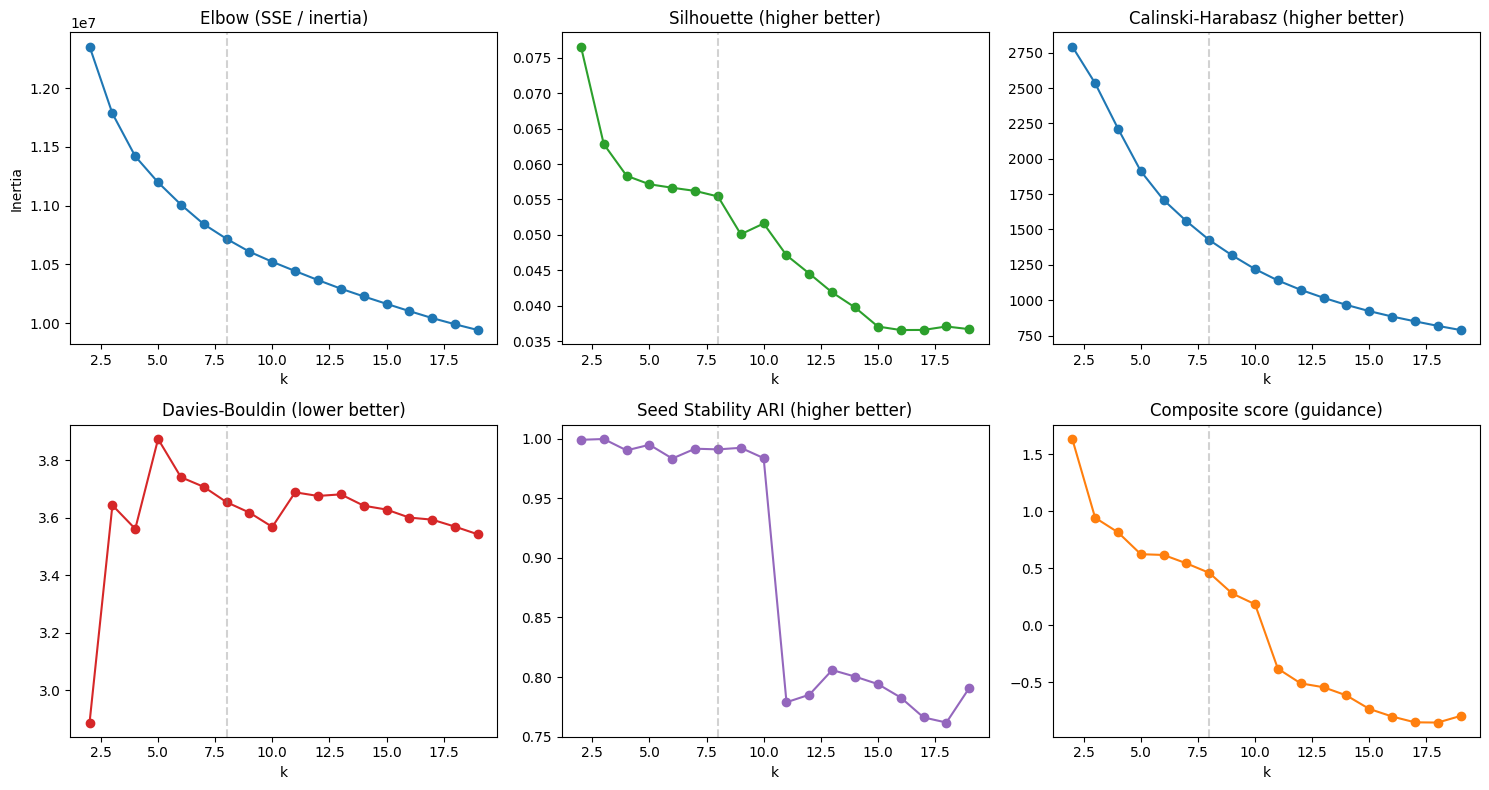

In [5]:
# plot metrics curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(k_eval_df['k'], k_eval_df['inertia_mean'], marker='o')
axes[0, 0].set_title('Elbow (SSE / inertia)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(k_eval_df['k'], k_eval_df['silhouette_mean'], marker='o', color='tab:green')
axes[0, 1].set_title('Silhouette (higher better)')
axes[0, 1].set_xlabel('k')

axes[0, 2].plot(k_eval_df['k'], k_eval_df['calinski_harabasz_mean'], marker='o', color='tab:blue')
axes[0, 2].set_title('Calinski-Harabasz (higher better)')
axes[0, 2].set_xlabel('k')

axes[1, 0].plot(k_eval_df['k'], k_eval_df['davies_bouldin_mean'], marker='o', color='tab:red')
axes[1, 0].set_title('Davies-Bouldin (lower better)')
axes[1, 0].set_xlabel('k')

axes[1, 1].plot(k_eval_df['k'], k_eval_df['seed_stability_ari_mean'], marker='o', color='tab:purple')
axes[1, 1].set_title('Seed Stability ARI (higher better)')
axes[1, 1].set_xlabel('k')

axes[1, 2].plot(k_eval_df['k'], k_eval_df['composite_score'], marker='o', color='tab:orange')
axes[1, 2].set_title('Composite score (guidance)')
axes[1, 2].set_xlabel('k')

for ax in axes.ravel():
    ax.axvline(8, linestyle='--', alpha=0.35, color='gray')

plt.tight_layout()
plt.show()

In [6]:
try:
    from IPython.display import display
except Exception:
    display = print

# ranking table + k=8 diagnosis
show_cols = [
    'k', 'inertia_mean', 'silhouette_mean', 'calinski_harabasz_mean',
    'davies_bouldin_mean', 'seed_stability_ari_mean', 'size_cv_mean',
    'min_cluster_frac_mean', 'composite_score'
]

display(k_eval_df[show_cols].sort_values('composite_score', ascending=False).round(4))

best_k_sil = int(k_eval_df.loc[k_eval_df['silhouette_mean'].idxmax(), 'k'])
best_k_comp = int(k_eval_df.loc[k_eval_df['composite_score'].idxmax(), 'k'])

print(f'Best k by silhouette: {best_k_sil}')
print(f'Best k by composite score: {best_k_comp}')

k8_row = k_eval_df[k_eval_df['k'] == 8]
if len(k8_row) == 1:
    k8_rank = int(k_eval_df['composite_score'].rank(ascending=False, method='min')[k_eval_df['k'] == 8].iloc[0])
    print('\n[k=8 diagnostic]')
    print(k8_row[show_cols].round(4).to_string(index=False))
    print(f'k=8 composite rank: {k8_rank} / {len(k_eval_df)}')

recommended_k = 8
print(f'\nRecommended (user preference): k={recommended_k}')


,k,inertia_mean,silhouette_mean,calinski_harabasz_mean,davies_bouldin_mean,seed_stability_ari_mean,size_cv_mean,min_cluster_frac_mean,composite_score
0,2,12354364.8,0.0766,2793.6204,2.8883,0.9989,0.6551,0.1725,1.6360
1,3,11784333.2,0.0628,2533.9473,3.6434,0.9996,0.4416,0.1476,0.9441
2,4,11419716.0,0.0583,2213.8758,3.5612,0.9901,0.3559,0.1446,0.8162
3,5,11197771.2,0.0571,1912.4046,3.8734,0.9947,0.2530,0.1426,0.6237
4,6,11008504.4,0.0567,1708.2547,3.7407,0.9832,0.1787,0.1219,0.6171
5,7,10842021.6,0.0562,1558.5435,3.7072,0.9914,0.1715,0.0950,0.5430
6,8,10717049.2,0.0554,1425.1081,3.6539,0.9909,0.2037,0.0866,0.4594
7,9,10607755.2,0.0501,1316.7369,3.6176,0.9922,0.2039,0.0740,0.2786
8,10,10521823.4,0.0516,1220.0920,3.5681,0.9836,0.2758,0.0496,0.1841
9,11,10443203.4,0.0471,1139.6125,3.6882,0.7789,0.2500,0.0500,-0.3822


Best k by silhouette: 2
Best k by composite score: 2

[k=8 diagnostic]
 k  inertia_mean  silhouette_mean  calinski_harabasz_mean  davies_bouldin_mean  seed_stability_ari_mean  size_cv_mean  min_cluster_frac_mean  composite_score
 8    10717049.2           0.0554               1425.1081               3.6539                   0.9909        0.2037                 0.0866           0.4594
k=8 composite rank: 7 / 18

Recommended (user preference): k=8


In [18]:
from sklearn.cluster import KMeans

n_clusters = 8  # choose a number for k
kmeans = KMeans(n_clusters=n_clusters, n_init=5,random_state=0).fit(features_pca)

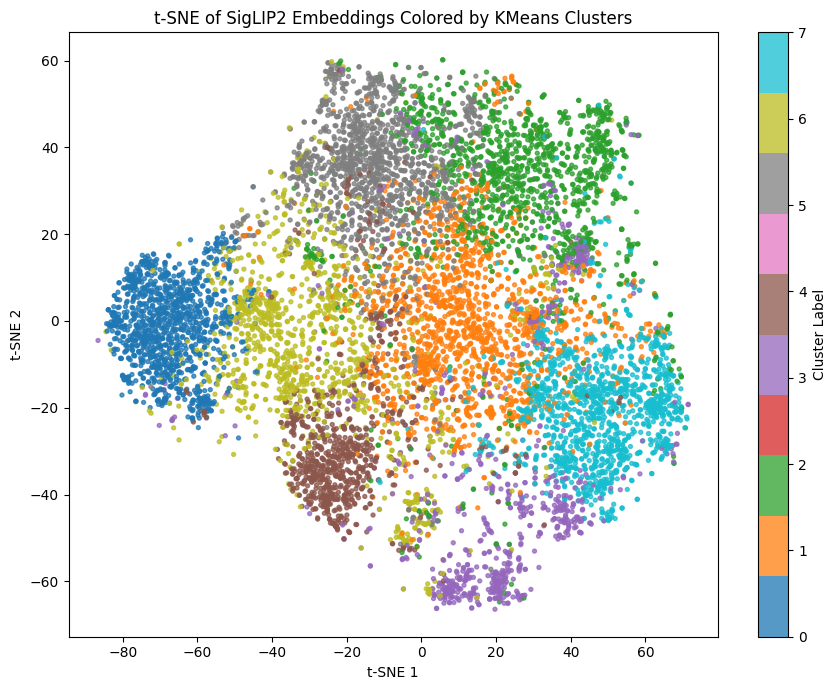

In [19]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE visualization of cluster result
n_samples = min(len(features), 10000)  # speed-up for large datasets
rng = np.random.RandomState(42)
idx = rng.choice(len(features), size=n_samples, replace=False) if len(features) > n_samples else np.arange(len(features))

features_vis = features[idx]
labels_vis = np.array(kmeans.labels_)[idx]

tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
features_2d = tsne.fit_transform(features_vis)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_vis, s=8, cmap='tab10', alpha=0.75)
plt.title('t-SNE of SigLIP2 Embeddings Colored by KMeans Clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='Cluster Label')
plt.tight_layout()
plt.show()

In [20]:
# Persist: embedding row index -> grid_id + cluster (after k-means)
import numpy as np
import pandas as pd
from pathlib import Path

P = Path('data_post_embedding')
map_df = pd.DataFrame({
    'embedding_index': np.arange(len(kmeans.labels_), dtype=np.int64),
    'grid_id': embedding_grid_id,
    'cluster': kmeans.labels_.astype(np.int64),
})
out_csv = P / 'embedding_index_grid_cluster.csv'
map_df.to_csv(out_csv, index=False)
print('Saved', out_csv, map_df.shape)

Saved data_post_embedding/embedding_index_grid_cluster.csv (44228, 3)


<a id="sec-3-viz"></a>

## 3. Do Visualization based on Categorization Result

This section gets total numbers of activity-related posts and do city-level intensity mapping per activity.

**Inputs:**
- Grid points coordinates: `data_post_embedding/grid_point_coordinates.csv` with columns **`id`**, **`longitude`**, **`latitude`** for 2096 grid points in Singapore.
- Post clustering result and located grid point: `data_post_embedding/embedding_index_grid_cluster.csv` from the clustering step (columns `embedding_index`, `grid_id`, `cluster`).
- Activity explanation for each cluster (human label): `data_post_embedding/cluster_activity_config.json`.

**Outputs:**
- geopackage file for social activity intensity: `data_post_embedding/data_social_activity.gpkg`.


In [21]:
# Setup
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Point

P = Path('data_post_embedding')
POINTS_CSV = P / 'grid_point_coordinates.csv'  # must include id, longitude, latitude

df = pd.read_csv(POINTS_CSV)
print('Loaded points:', POINTS_CSV.resolve(), df.shape)

Loaded points: /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/grid_point_coordinates.csv (2096, 14)


In [22]:
# Per-grid activity counts from embedding_index_grid_cluster.csv + cluster_activity_config.json
map_csv = P / 'embedding_index_grid_cluster.csv'
if not map_csv.exists():
    raise FileNotFoundError(
        f'Missing {map_csv}. Run section 2 (KMeans) once to export it, or place the CSV under {P.resolve()}.'
    )

map_df = pd.read_csv(map_csv)
for col in ('grid_id', 'cluster'):
    if col not in map_df.columns:
        raise ValueError(f'{map_csv} must contain column {col!r}')

cfg_path = P / 'cluster_activity_config.json'
if not cfg_path.exists():
    raise FileNotFoundError(f'Missing {cfg_path}. Place cluster_activity_config.json under {P.resolve()}.')
cfg = json.loads(cfg_path.read_text(encoding='utf-8'))
drop = set(int(x) for x in cfg.get('drop_clusters', []))
raw_map = cfg.get('cluster_to_activity', {})
cluster_to_activity = {}
for k, v in raw_map.items():
    if v is None or str(v).lower() in ('null', 'none', ''):
        continue
    cluster_to_activity[int(k)] = str(v).strip().lower()

ACT = ['eating', 'nature', 'community', 'walking', 'sightseeing']
for a in cluster_to_activity.values():
    if a not in ACT:
        raise ValueError(f'Unknown activity {a!r}; use one of {ACT}')

labels = map_df['cluster'].astype(np.int64).values
gid = map_df['grid_id'].astype(np.int64).values

activity = []
for i in range(len(labels)):
    c = int(labels[i])
    if c in drop:
        activity.append(None)
        continue
    activity.append(cluster_to_activity.get(c))
emb_act = pd.DataFrame({'grid_id': gid, 'activity': activity})
emb_act = emb_act[emb_act['grid_id'] >= 0]
emb_act = emb_act[emb_act['activity'].notna()]

if emb_act.empty:
    print('Warning: no embeddings counted (check grid_id and cluster mapping).')
else:
    counts = emb_act.groupby(['grid_id', 'activity']).size().unstack(fill_value=0)
    for a in ACT:
        if a not in counts.columns:
            counts[a] = 0
    counts = counts[ACT]
    df_idx = df.set_index('id')
    for a in ACT:
        df_idx[a] = df_idx.index.map(counts[a].to_dict()).fillna(0).astype(int)
    df = df_idx.reset_index()
    print('Attached activity count columns:', ACT)

Attached activity count columns: ['eating', 'nature', 'community', 'walking', 'sightseeing']


In [23]:
# Convert DataFrame to GeoDataFrame; save both GPKG and grid_point_coordinates.csv
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))
output_gpkg = P / 'data_social_activity.gpkg'
gdf.to_file(output_gpkg, driver='GPKG')
df.to_csv(POINTS_CSV, index=False, encoding='utf-8-sig')
print('Saved GPKG:', output_gpkg.resolve())
print('Updated CSV:', POINTS_CSV.resolve())
gdf


Saved GPKG: /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/data_social_activity.gpkg
Updated CSV: /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/grid_point_coordinates.csv


/Users/sijieyang/anaconda3/lib/python3.11/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


,id,longitude,latitude,eating,nature,community,walking,sightseeing,avg_comfort_score,avg_comfort_eating,avg_comfort_nature,avg_comfort_community,avg_comfort_walking,avg_comfort_sightseeing,geometry
0,0,103.610,1.230,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (103.61 1.23)
1,1,103.610,1.235,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (103.61 1.235)
2,2,103.610,1.250,8,1,3,11,13,0.559116,0.561076,0.357431,0.572966,0.535751,0.565555,POINT (103.61 1.25)
3,3,103.610,1.260,0,0,0,5,1,0.540892,0.000000,0.000000,0.502814,0.548579,0.548223,POINT (103.61 1.26)
4,4,103.610,1.265,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (103.61 1.265)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2091,2091,104.025,1.365,0,0,1,0,0,0.643017,0.000000,0.000000,0.643017,0.000000,0.000000,POINT (104.025 1.365)
2092,2092,104.030,1.320,4,2,1,7,6,0.689083,0.776289,0.775027,0.611131,0.720309,0.614321,POINT (104.03 1.32)
2093,2093,104.030,1.350,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (104.03 1.35)
2094,2094,104.030,1.355,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (104.03 1.355)


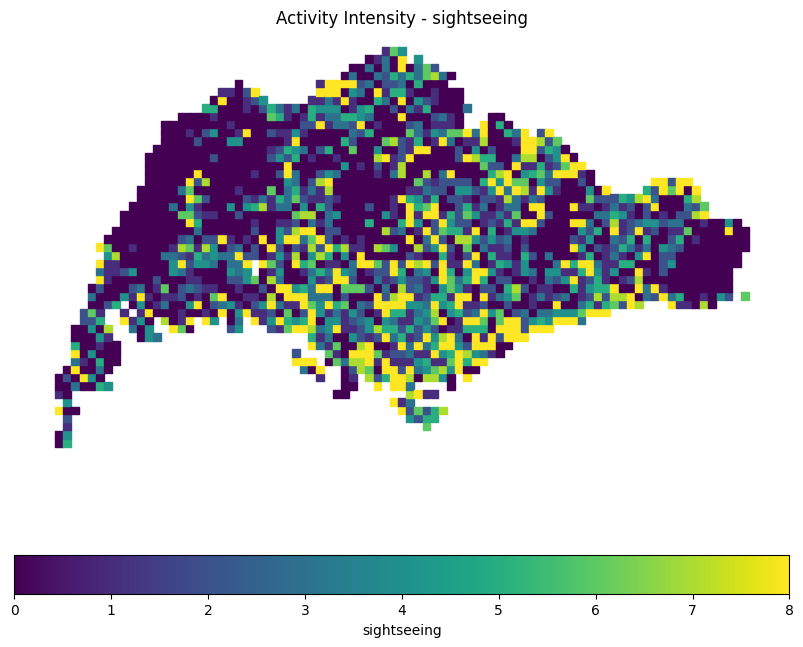

In [24]:
# Optional preview of one layer; next cell maps all five activities the same way.
PREVIEW_COL = 'sightseeing'
if PREVIEW_COL not in gdf.columns:
    raise KeyError(f"gdf missing column {PREVIEW_COL!r}; run the aggregation cell above first.")
vmin = float(gdf[PREVIEW_COL].quantile(0.10))
vmax = float(gdf[PREVIEW_COL].quantile(0.90))
ax = gdf.plot(
    column=PREVIEW_COL,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax,
    figsize=(10, 8),
    legend=True,
    legend_kwds={'label': PREVIEW_COL, 'orientation': 'horizontal'},
    markersize=30,
    marker='s',
    missing_kwds={'color': 'lightgrey'},
)
ax.set_title(f'Activity Intensity - {PREVIEW_COL}')
ax.set_axis_off()
plt.show()

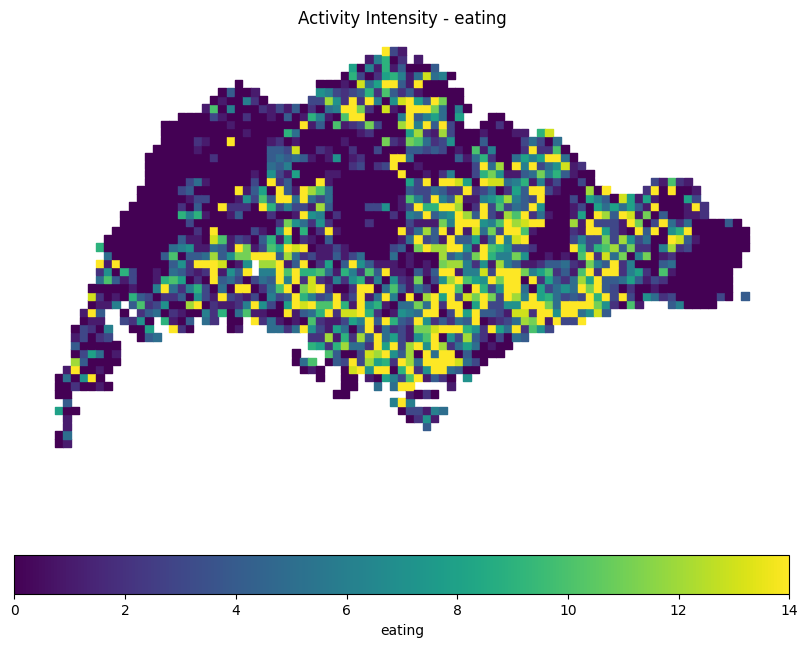

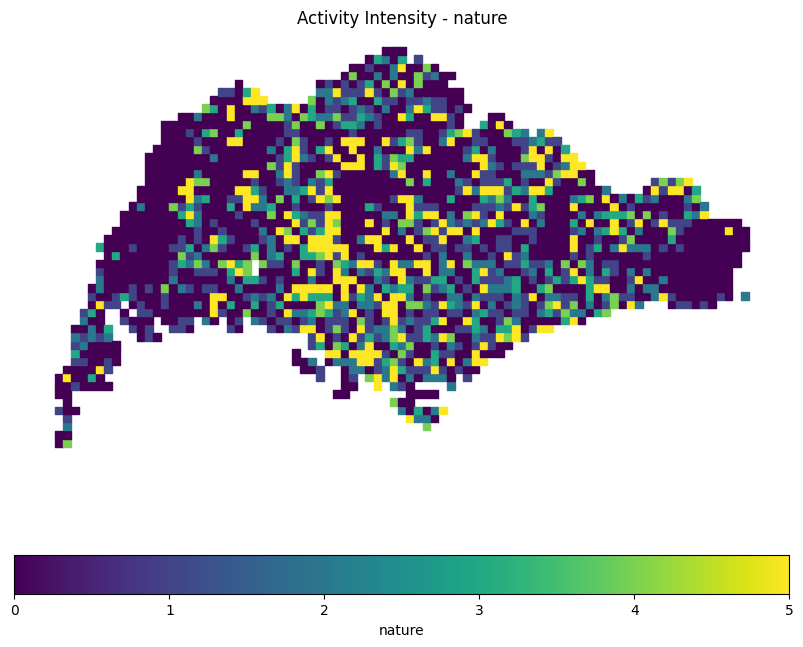

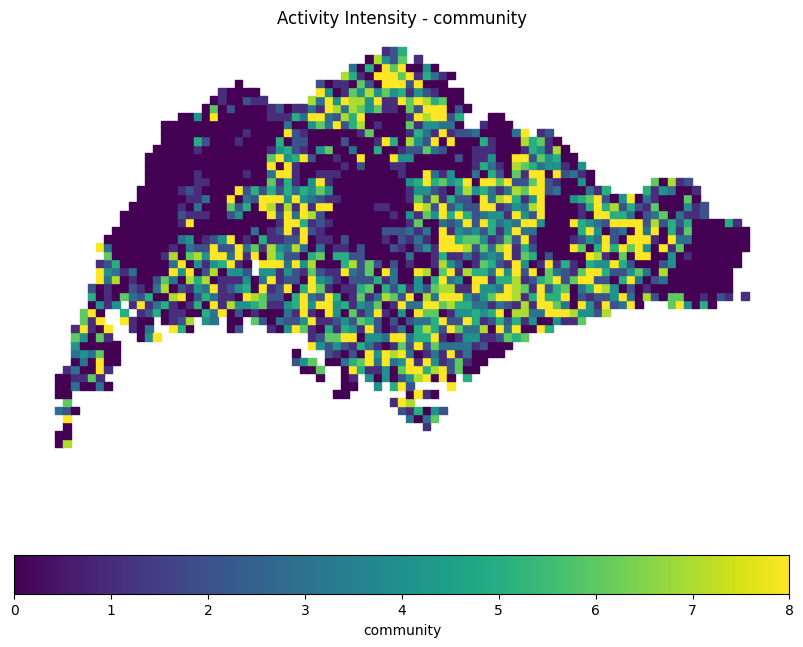

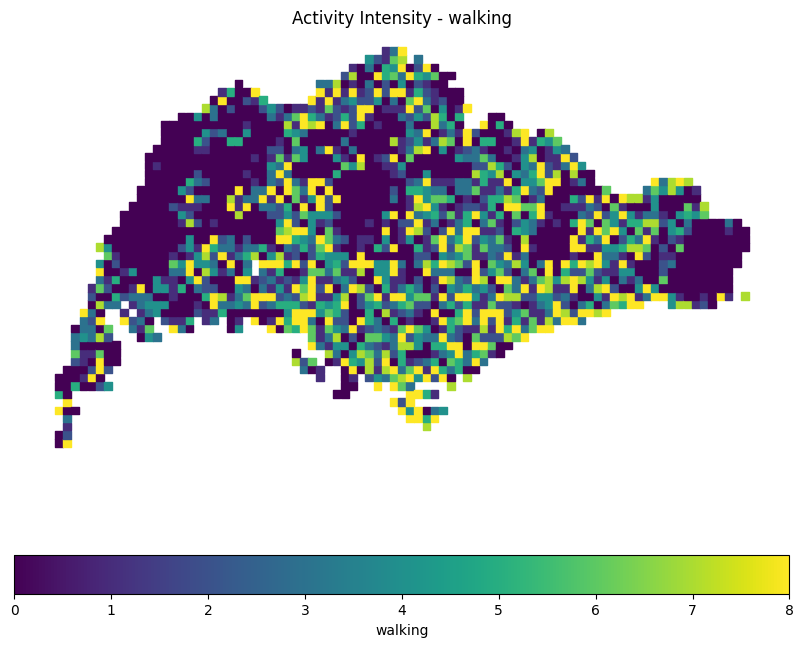

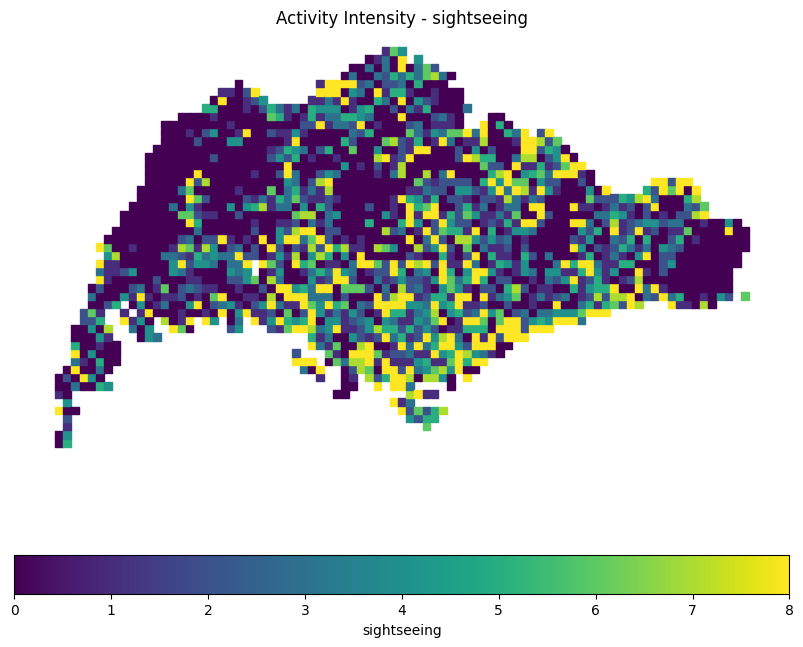

In [25]:
# Maps per activity

ACT_COLS = ['eating', 'nature', 'community', 'walking', 'sightseeing']

for col in ACT_COLS:
    if col not in gdf.columns:
        raise KeyError(f"gdf missing column {col!r}; run the aggregation cell above first.")
    vmin = float(gdf[col].quantile(0.10))
    vmax = float(gdf[col].quantile(0.90))
    ax = gdf.plot(
        column=col,
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        figsize=(10, 8),
        legend=True,
        legend_kwds={'label': col, 'orientation': 'horizontal'},
        markersize=30,
        marker='s',
        missing_kwds={'color': 'lightgrey'},
    )
    ax.set_title(f'Activity Intensity - {col}')
    ax.set_axis_off()
    plt.show()

<a id="sec-4-caption"></a>

## 4. Caption analytics for comfort level evaluation

This section evaluates social activity comfort for each caption based on its embedding distance to pre-set comfort / discomfort anchors.

**Input:** 
- post-level text embeddings (model ***`all-MiniLM-L6-v2`***): `data_post_embedding/dataset_post_st_caption_features.npy` 
- post has text or not: `data_post_embedding/dataset_post_caption_has_text.npy` 

**Outputs:** 
- **§4.1** writes `data_post_embedding/dataset_post_comfort_*.npy`, indicating comfort / discomfort scores; 
- **§4.2** joins *cluster → activity* (`embedding_index_grid_cluster.csv` + `cluster_activity_config.json`) per row, assign activity type to each caption; 
- **§4.3** summarises and visualises comfort scores (captions with text); 
- **§4.4** merges overall and *per-activity* mean comfort into the grid CSV and refreshes the geopackage.
- **§5** (optional next step) recomputes `social_activity_comfort_*`, overwrites the GPKG, and plots maps.


In [26]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd

P = Path('data_post_embedding')

<a id="sec-4-1-comfort"></a>

### 4.1 Comfort scores from post-level caption embeddings

Loads `data_post_embedding/dataset_post_st_caption_features.npy` and `data_post_embedding/dataset_post_caption_has_text.npy`. 

Encodes anchor sentences with the same ***`all-MiniLM-L6-v2`*** model, then writes `data_post_embedding/dataset_post_comfort_*.npy`.


In [27]:
# 4.1 Comfort: only .npy inputs (no caption CSV)
from sentence_transformers import SentenceTransformer

cap_emb = np.load(P / 'dataset_post_st_caption_features.npy').astype(np.float32)
has_text_np = np.load(P / 'dataset_post_caption_has_text.npy').astype(bool)
n = len(has_text_np)
if cap_emb.shape[0] != n:
    raise ValueError(f'cap_emb rows {cap_emb.shape[0]} != has_text {n}')

model = SentenceTransformer('all-MiniLM-L6-v2')

comfort_anchors = [
    "A pleasant, clean, safe, and visually appealing street environment with greenery, good lighting, and an inviting atmosphere.",
    "A functional urban place where services, amenities, and everyday activities are convenient and well supported.",
    "A highly accessible place with walkable streets, smooth movement, barrier-free design, convenient access to public transport such as buses and metro, and strong connectivity to surrounding destinations within the urban network.",
    "A socially comfortable environment with lively public interaction and an active atmosphere, but without overcrowding or excessive social pressure.",
]
discomfort_anchors = [
    "An unpleasant, dirty, unsafe, and visually stressful street environment with poor lighting and an uninviting atmosphere.",
    "A dysfunctional urban place where services, amenities, and everyday activities are inconvenient or poorly supported.",
    "A poorly accessible place with difficult walking conditions, physical barriers, inconvenient movement, limited access to public transport such as buses and metro, and weak connectivity to surrounding destinations within the urban network.",
    "A socially uncomfortable environment that feels either overcrowded, chaotic, and oppressive, or isolated, inactive, and lacking meaningful public interaction.",
]

comfort_emb = model.encode(comfort_anchors, normalize_embeddings=True)
discomfort_emb = model.encode(discomfort_anchors, normalize_embeddings=True)

idx = np.flatnonzero(has_text_np)
avg_c = np.full(n, np.nan, dtype=np.float32)
avg_d = np.full(n, np.nan, dtype=np.float32)
raw = np.full(n, np.nan, dtype=np.float32)

if len(idx) > 0:
    sim_c = cap_emb[idx] @ comfort_emb.T
    sim_d = cap_emb[idx] @ discomfort_emb.T
    avg_c[idx] = sim_c.mean(axis=1).astype(np.float32)
    avg_d[idx] = sim_d.mean(axis=1).astype(np.float32)
    raw[idx] = avg_c[idx] - avg_d[idx]

finite = np.isfinite(raw)
score = np.full(n, np.nan, dtype=np.float32)
if finite.any():
    lo, hi = float(raw[finite].min()), float(raw[finite].max())
    if hi > lo:
        score[finite] = ((raw[finite] - lo) / (hi - lo)).astype(np.float32)
    else:
        score[finite] = 0.5

np.save(P / 'dataset_post_comfort_anchor_sim_mean.npy', avg_c)
np.save(P / 'dataset_post_discomfort_anchor_sim_mean.npy', avg_d)
np.save(P / 'dataset_post_comfort_raw_score.npy', raw.astype(np.float32))
np.save(P / 'dataset_post_comfort_score.npy', score)
print('Saved comfort *.npy under', P.resolve())


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved comfort *.npy under /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding


<a id="sec-4-2-integrate"></a>

### 4.2 Integrate comfort scores for each post with its activity types

Rebuild comfort columns from disk; attach `cluster` and `activity` from `embedding_index_grid_cluster.csv` and `cluster_activity_config.json` (same rules as §3). 

Saves `data_post_embedding/dataset_post_caption_activity.npy` (empty string = no mapped activity).


In [28]:
# Build df_captions from disk + activity (cluster → activity via cluster_activity_config.json)
import json

has_text = np.load(P / 'dataset_post_caption_has_text.npy').astype(bool)
avg_c = np.load(P / 'dataset_post_comfort_anchor_sim_mean.npy').astype(np.float32)
avg_d = np.load(P / 'dataset_post_discomfort_anchor_sim_mean.npy').astype(np.float32)
raw = np.load(P / 'dataset_post_comfort_raw_score.npy').astype(np.float32)
score = np.load(P / 'dataset_post_comfort_score.npy').astype(np.float32)

gid_path = P / 'dataset_post_embedding_grid_id.npy'
if gid_path.exists():
    gid = np.load(gid_path).astype(np.int64).reshape(-1)
else:
    gid = np.full(len(has_text), -1, dtype=np.int64)

n = min(len(has_text), len(avg_c), len(avg_d), len(raw), len(score), len(gid))

map_csv = P / 'embedding_index_grid_cluster.csv'
if not map_csv.exists():
    raise FileNotFoundError(map_csv)
map_df = pd.read_csv(map_csv)
if 'embedding_index' in map_df.columns:
    map_df = map_df.sort_values('embedding_index').drop_duplicates('embedding_index', keep='first').reset_index(drop=True)
cfg_path = P / 'cluster_activity_config.json'
if not cfg_path.exists():
    raise FileNotFoundError(f'Missing {cfg_path}. Place cluster_activity_config.json under {P.resolve()}.')
cfg = json.loads(cfg_path.read_text(encoding='utf-8'))
drop = set(int(x) for x in cfg.get('drop_clusters', []))
raw_map = cfg.get('cluster_to_activity', {})
cluster_to_activity = {}
for k, v in raw_map.items():
    if v is None or str(v).lower() in ('null', 'none', ''):
        continue
    cluster_to_activity[int(k)] = str(v).strip().lower()

ACT = ['eating', 'nature', 'community', 'walking', 'sightseeing']
for a in cluster_to_activity.values():
    if a not in ACT:
        raise ValueError(f'Unknown activity {a!r} in cluster_activity_config.json; use one of {ACT}')

if len(map_df) < n:
    raise ValueError(f'{map_csv} rows {len(map_df)} < caption rows {n}')
map_df = map_df.iloc[:n].reset_index(drop=True)
clusters = map_df['cluster'].astype(np.int64).values
activity = []
for i in range(n):
    c = int(clusters[i])
    if c in drop:
        activity.append(None)
    else:
        activity.append(cluster_to_activity.get(c))

df_captions = pd.DataFrame({
    'embedding_index': np.arange(n, dtype=np.int64),
    'grid_id': gid[:n],
    'cluster': clusters,
    'activity': activity,
    'has_text': has_text[:n],
    'comfort_anchor_similarity': avg_c[:n],
    'discomfort_anchor_similarity': avg_d[:n],
    'comfort_raw_score': raw[:n],
    'comfort_score': score[:n],
})

act_np = np.array([x if x is not None else '' for x in activity], dtype=object)
np.save(P / 'dataset_post_caption_activity.npy', act_np)

print(df_captions.shape)
print('activity (non-null):')
print(df_captions['activity'].value_counts(dropna=True))
df_captions.head()


(44228, 9)
activity (non-null):
activity
eating         10326
walking         6473
community       6459
sightseeing     6201
nature          3777
Name: count, dtype: int64


,embedding_index,grid_id,cluster,activity,has_text,comfort_anchor_similarity,discomfort_anchor_similarity,comfort_raw_score,comfort_score
0,0,2,2,walking,True,0.030963,0.035113,-0.004150,0.513033
1,1,2,1,None,True,0.101564,0.125953,-0.024389,0.454412
2,2,2,6,eating,True,0.057414,0.062779,-0.005365,0.509514
3,3,2,7,sightseeing,True,0.240415,0.252698,-0.012283,0.489476
4,4,2,5,community,False,NaN,NaN,NaN,NaN


<a id="sec-4-3-summary"></a>

### 4.3 Overall score summary and visualisation

Histograms / pie chart use rows with `has_text` only.


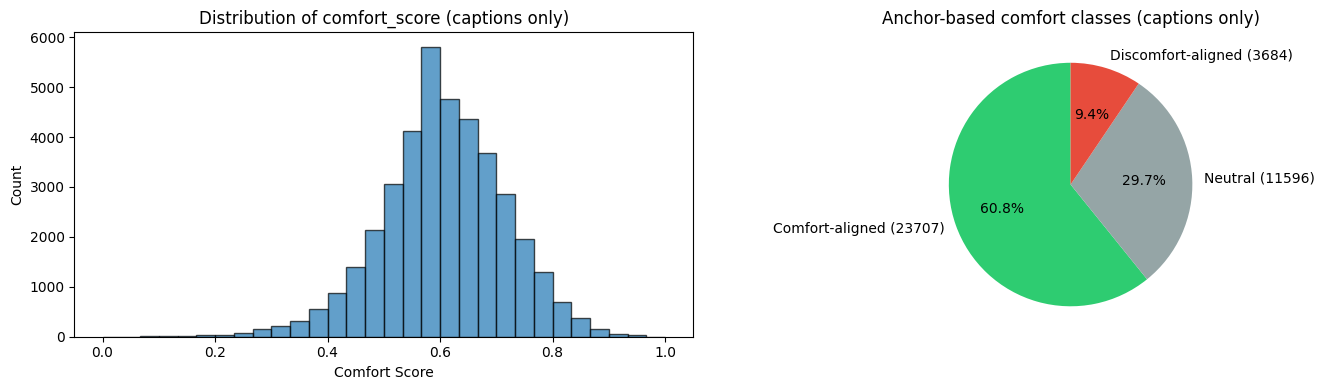

In [29]:
# Plots (text rows only)
sub = df_captions.loc[df_captions['has_text']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sub['comfort_score'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Comfort Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of comfort_score (captions only)')

comfort_aligned = (sub['comfort_raw_score'] > 0.02).sum()
neutral = ((sub['comfort_raw_score'] >= -0.02) & (sub['comfort_raw_score'] <= 0.02)).sum()
discomfort_aligned = (sub['comfort_raw_score'] < -0.02).sum()
sizes = [comfort_aligned, neutral, discomfort_aligned]
labels = [f'Comfort-aligned ({comfort_aligned})', f'Neutral ({neutral})', f'Discomfort-aligned ({discomfort_aligned})']
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Anchor-based comfort classes (captions only)')

plt.tight_layout()
plt.show()


In [30]:
# Export without any comment text (numeric flags only)
sub = df_captions.loc[df_captions['has_text']]
print('=== Comfort score (rows with text) ===')
print(f"Total embedding rows: {len(df_captions)}")
print(f"Rows with caption encoded: {len(sub)}")
if len(sub):
    print(f"comfort_score mean: {sub['comfort_score'].mean():.4f}")
    print(sub['comfort_score'].describe())

out_csv = P / 'caption_analytics_results.csv'
df_captions.to_csv(out_csv, index=False, encoding='utf-8-sig')
print('Saved (no raw captions):', out_csv.resolve())


=== Comfort score (rows with text) ===
Total embedding rows: 44228
Rows with caption encoded: 38987
comfort_score mean: 0.6063
count    38987.000000
mean         0.606277
std          0.108758
min          0.000000
25%          0.541437
50%          0.604987
75%          0.677597
max          1.000000
Name: comfort_score, dtype: float64
Saved (no raw captions): /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/caption_analytics_results.csv


<a id="sec-4-4-merge"></a>

### 4.4 Merge comfort into grid point and geopackage file

*Overall* mean `comfort_score` (`avg_comfort_score`) and *per-activity* means (`avg_comfort_eating`, …, `avg_comfort_sightseeing`) per grid `id`, using rows with `has_text` and a non-null `activity`. Replaces any existing `avg_comfort_*` columns.

**Updated:**
- `data_post_embedding/grid_point_coordinates.csv`
- `data_post_embedding/data_social_activity.gpkg`


In [33]:
# Mean comfort per grid: overall + per activity → grid_point_coordinates.csv
ACT = ['eating', 'nature', 'community', 'walking', 'sightseeing']

points_path = P / 'grid_point_coordinates.csv'
if not points_path.exists():
    raise FileNotFoundError(points_path)

pts = pd.read_csv(points_path)
drop_legacy = [c for c in pts.columns if c.startswith('avg_comfort_')]
if drop_legacy:
    pts = pts.drop(columns=drop_legacy)

scored = df_captions[(df_captions['grid_id'] >= 0) & df_captions['has_text']].copy()

location_avg = (
    scored.groupby('grid_id', as_index=False)['comfort_score']
    .mean()
    .rename(columns={'grid_id': 'id', 'comfort_score': 'avg_comfort_score'})
)

sub_act = scored[scored['activity'].notna()].copy()

pts['id'] = pd.to_numeric(pts['id'], errors='coerce')
location_avg['id'] = pd.to_numeric(location_avg['id'], errors='coerce')

pts = pts.merge(location_avg, on='id', how='left')

if len(sub_act) > 0:
    cat_avg = (
        sub_act.groupby(['grid_id', 'activity'])['comfort_score']
        .mean()
        .unstack('activity')
    )
    for a in ACT:
        if a not in cat_avg.columns:
            cat_avg[a] = np.nan
    cat_avg = cat_avg[ACT]
    cat_avg = cat_avg.add_prefix('avg_comfort_').reset_index().rename(columns={'grid_id': 'id'})
    cat_avg['id'] = pd.to_numeric(cat_avg['id'], errors='coerce')
    pts = pts.merge(cat_avg, on='id', how='left')
else:
    for a in ACT:
        pts[f'avg_comfort_{a}'] = 0.0

score_cols = ['avg_comfort_score'] + [f'avg_comfort_{a}' for a in ACT]
for col in score_cols:
    if col in pts.columns:
        pts[col] = pts[col].fillna(0)

pts.to_csv(points_path, index=False, encoding='utf-8-sig')
print('Updated CSV:', points_path.resolve())

output_gpkg = P / 'data_social_activity.gpkg'
gdf_comfort = gpd.GeoDataFrame(pts, geometry=gpd.points_from_xy(pts.longitude, pts.latitude))
gdf_comfort.to_file(output_gpkg, driver='GPKG')
print('Saved GPKG:', output_gpkg.resolve())

show_cols = ['id', 'avg_comfort_score'] + [f'avg_comfort_{a}' for a in ACT if f'avg_comfort_{a}' in pts.columns]
print(pts[show_cols].head())


Updated CSV: /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/grid_point_coordinates.csv
Saved GPKG: /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/data_social_activity.gpkg
   id  avg_comfort_score  avg_comfort_eating  avg_comfort_nature  \
0   0           0.000000            0.000000            0.000000   
1   1           0.000000            0.000000            0.000000   
2   2           0.559116            0.561076            0.357431   
3   3           0.540892            0.000000            0.000000   
4   4           0.000000            0.000000            0.000000   

   avg_comfort_community  avg_comfort_walking  avg_comfort_sightseeing  
0                0.00000             0.000000                 0.000000  
1                0.00000             0.000000                 0.000000  
2                0.46878             0.535751                 0.565555  
3                0.00000             0.548579                 0.5

/Users/sijieyang/anaconda3/lib/python3.11/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


<a id="sec-5-result-viz"></a>

## 5. Result visualisation

Reads `data_post_embedding/data_social_activity.gpkg` (activity intensity columns from §3, comfort columns from §4.4) and `data_post_embedding/grid_point_coordinates.csv`, merges any `avg_comfort_*` scores by `id`, imputes category comfort where activity > 0 but comfort is 0, computes **social activity comfort** = activity × category comfort, writes the GPKG back, and maps each category in a 3-panel row (activity | comfort | product).

**Prerequisites:** Run §3 (GPKG with `eating`, …, `sightseeing`) and §4.4 (CSV + GPKG with `avg_comfort_*`). You can instead point `gpkg_path` / `points_csv_path` at other files if needed.


In [34]:
import pandas as pd
import geopandas as gpd
import fiona
from pathlib import Path

P = Path('data_post_embedding')

In [35]:
# Input paths (same pipeline as §3–§4)
gpkg_path = P / 'data_social_activity.gpkg'
points_csv_path = P / 'grid_point_coordinates.csv'

if not gpkg_path.exists():
    raise FileNotFoundError(f'GeoPackage not found: {gpkg_path}')
if not points_csv_path.exists():
    raise FileNotFoundError(f'CSV not found: {points_csv_path}')

layers = fiona.listlayers(str(gpkg_path))
print("Available layers:", layers)

Available layers: ['data_social_activity']


In [36]:
layer_name = layers[0]
gdf = gpd.read_file(gpkg_path, layer=layer_name)
points_df = pd.read_csv(points_csv_path)

print("GPKG rows:", len(gdf))
print("CSV rows:", len(points_df))
print("GPKG columns:", list(gdf.columns))
print("CSV columns:", list(points_df.columns))

GPKG rows: 2096
CSV rows: 2096
GPKG columns: ['id', 'longitude', 'latitude', 'eating', 'nature', 'community', 'walking', 'sightseeing', 'avg_comfort_score', 'avg_comfort_eating', 'avg_comfort_nature', 'avg_comfort_community', 'avg_comfort_walking', 'avg_comfort_sightseeing', 'geometry']
CSV columns: ['id', 'longitude', 'latitude', 'eating', 'nature', 'community', 'walking', 'sightseeing', 'avg_comfort_score', 'avg_comfort_eating', 'avg_comfort_nature', 'avg_comfort_community', 'avg_comfort_walking', 'avg_comfort_sightseeing']


In [37]:
# Ensure both sides use numeric id for alignment
if 'id' not in gdf.columns:
    raise KeyError("Column 'id' not found in GeoPackage layer. Please check gdf.columns and update the join key.")
if 'id' not in points_df.columns:
    raise KeyError("Column 'id' not found in grid_point_coordinates.csv.")

# Collect all score columns from points file
score_cols = [c for c in points_df.columns if c.startswith('avg_comfort_')]
if len(score_cols) == 0:
    raise KeyError("No comfort columns found in grid_point_coordinates.csv (expected columns starting with 'avg_comfort_').")

gdf['id'] = pd.to_numeric(gdf['id'], errors='coerce')
points_df['id'] = pd.to_numeric(points_df['id'], errors='coerce')

# Prefer CSV comfort columns over any stale copies already in the GPKG
drop_from_gpkg = [c for c in score_cols if c in gdf.columns]
if drop_from_gpkg:
    gdf = gdf.drop(columns=drop_from_gpkg)

score_df = points_df[['id'] + score_cols].drop_duplicates(subset=['id'])
gdf_merged = gdf.merge(score_df, on='id', how='left')

category_pairs = [
    ("eating", "avg_comfort_eating", "social_activity_comfort_eating"),
    ("nature", "avg_comfort_nature", "social_activity_comfort_nature"),
    ("community", "avg_comfort_community", "social_activity_comfort_community"),
    ("walking", "avg_comfort_walking", "social_activity_comfort_walking"),
    ("sightseeing", "avg_comfort_sightseeing", "social_activity_comfort_sightseeing"),
]

# If activity > 0 but the matching category comfort is 0, replace comfort with that column's mean
activity_comfort_impute = {}
for activity_col, score_col, _ in category_pairs:
    if activity_col not in gdf_merged.columns or score_col not in gdf_merged.columns:
        continue
    mask = (gdf_merged[activity_col].fillna(0) > 0) & (gdf_merged[score_col].fillna(0) == 0)
    ref = gdf_merged.loc[~mask, score_col].mean()
    if pd.isna(ref):
        ref = gdf_merged[score_col].mean()
    if pd.isna(ref):
        ref = 0.0
    n = int(mask.sum())
    activity_comfort_impute[score_col] = {"reference_mean": ref, "rows_imputed": n}
    if n > 0:
        gdf_merged.loc[mask, score_col] = ref
print(
    "Imputed category comfort where activity>0 and comfort==0 (using column mean):",
    activity_comfort_impute,
)

# Create new columns: social activity comfort = activity_intensity * avg_comfort_category
for activity_col, score_col, out_col in category_pairs:
    if activity_col in gdf_merged.columns and score_col in gdf_merged.columns:
        gdf_merged[out_col] = gdf_merged[activity_col].fillna(0) * gdf_merged[score_col].fillna(0)
    else:
        gdf_merged[out_col] = 0

new_cols = [x[2] for x in category_pairs]

activity_cols = [a for a, _, _ in category_pairs]
if 'avg_comfort_score' in gdf_merged.columns:
    n_zero_overall_comfort_but_activity = (
        (gdf_merged['avg_comfort_score'].fillna(0) == 0)
        & (gdf_merged[activity_cols].fillna(0).sum(axis=1) > 0)
    ).sum()
    print(
        "IDs with avg_comfort_score == 0 but sum(activity categories) > 0:",
        int(n_zero_overall_comfort_but_activity),
    )
for activity_col, score_col, _ in category_pairs:
    if activity_col not in gdf_merged.columns or score_col not in gdf_merged.columns:
        continue
    n_mismatch = (
        (gdf_merged[score_col].fillna(0) == 0)
        & (gdf_merged[activity_col].fillna(0) > 0)
    ).sum()
    print(
        f"IDs with {score_col} == 0 but {activity_col} > 0:",
        int(n_mismatch),
    )

print(gdf_merged[['id'] + score_cols + new_cols].head())
print("Merged score columns:", score_cols)
print("New social activity comfort columns:", new_cols)
print("Rows with all scores = 0:", (gdf_merged[score_cols].sum(axis=1) == 0).sum())


Imputed category comfort where activity>0 and comfort==0 (using column mean): {'avg_comfort_eating': {'reference_mean': np.float64(0.39007054956017395), 'rows_imputed': 27}, 'avg_comfort_nature': {'reference_mean': np.float64(0.2885632237865497), 'rows_imputed': 44}, 'avg_comfort_community': {'reference_mean': np.float64(0.3727075765242719), 'rows_imputed': 36}, 'avg_comfort_walking': {'reference_mean': np.float64(0.3758624917983519), 'rows_imputed': 33}, 'avg_comfort_sightseeing': {'reference_mean': np.float64(0.3594262064015709), 'rows_imputed': 59}}
IDs with avg_comfort_score == 0 but sum(activity categories) > 0: 15
IDs with avg_comfort_eating == 0 but eating > 0: 0
IDs with avg_comfort_nature == 0 but nature > 0: 0
IDs with avg_comfort_community == 0 but community > 0: 0
IDs with avg_comfort_walking == 0 but walking > 0: 0
IDs with avg_comfort_sightseeing == 0 but sightseeing > 0: 0
   id  avg_comfort_score  avg_comfort_eating  avg_comfort_nature  \
0   0           0.000000       

In [38]:
output_gpkg_path = P / 'data_social_activity.gpkg'

gdf_merged.to_file(output_gpkg_path, driver='GPKG', mode='w')

print("Saved merged GeoPackage:", output_gpkg_path.resolve())
print("All columns:")
print(list(gdf_merged.columns))

Saved merged GeoPackage: /Users/sijieyang/Documents/GitHub/Urban-Comfort-Potential/data_post_embedding/data_social_activity.gpkg
All columns:
['id', 'longitude', 'latitude', 'eating', 'nature', 'community', 'walking', 'sightseeing', 'geometry', 'avg_comfort_score', 'avg_comfort_eating', 'avg_comfort_nature', 'avg_comfort_community', 'avg_comfort_walking', 'avg_comfort_sightseeing', 'social_activity_comfort_eating', 'social_activity_comfort_nature', 'social_activity_comfort_community', 'social_activity_comfort_walking', 'social_activity_comfort_sightseeing']


/Users/sijieyang/anaconda3/lib/python3.11/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


### 5.1 Maps (3 panels per activity)

Each row: **left** — activity intensity in GPKG; **middle** — `avg_comfort_*` from the merge; **right** — `social_activity_comfort_*` = activity × comfort.


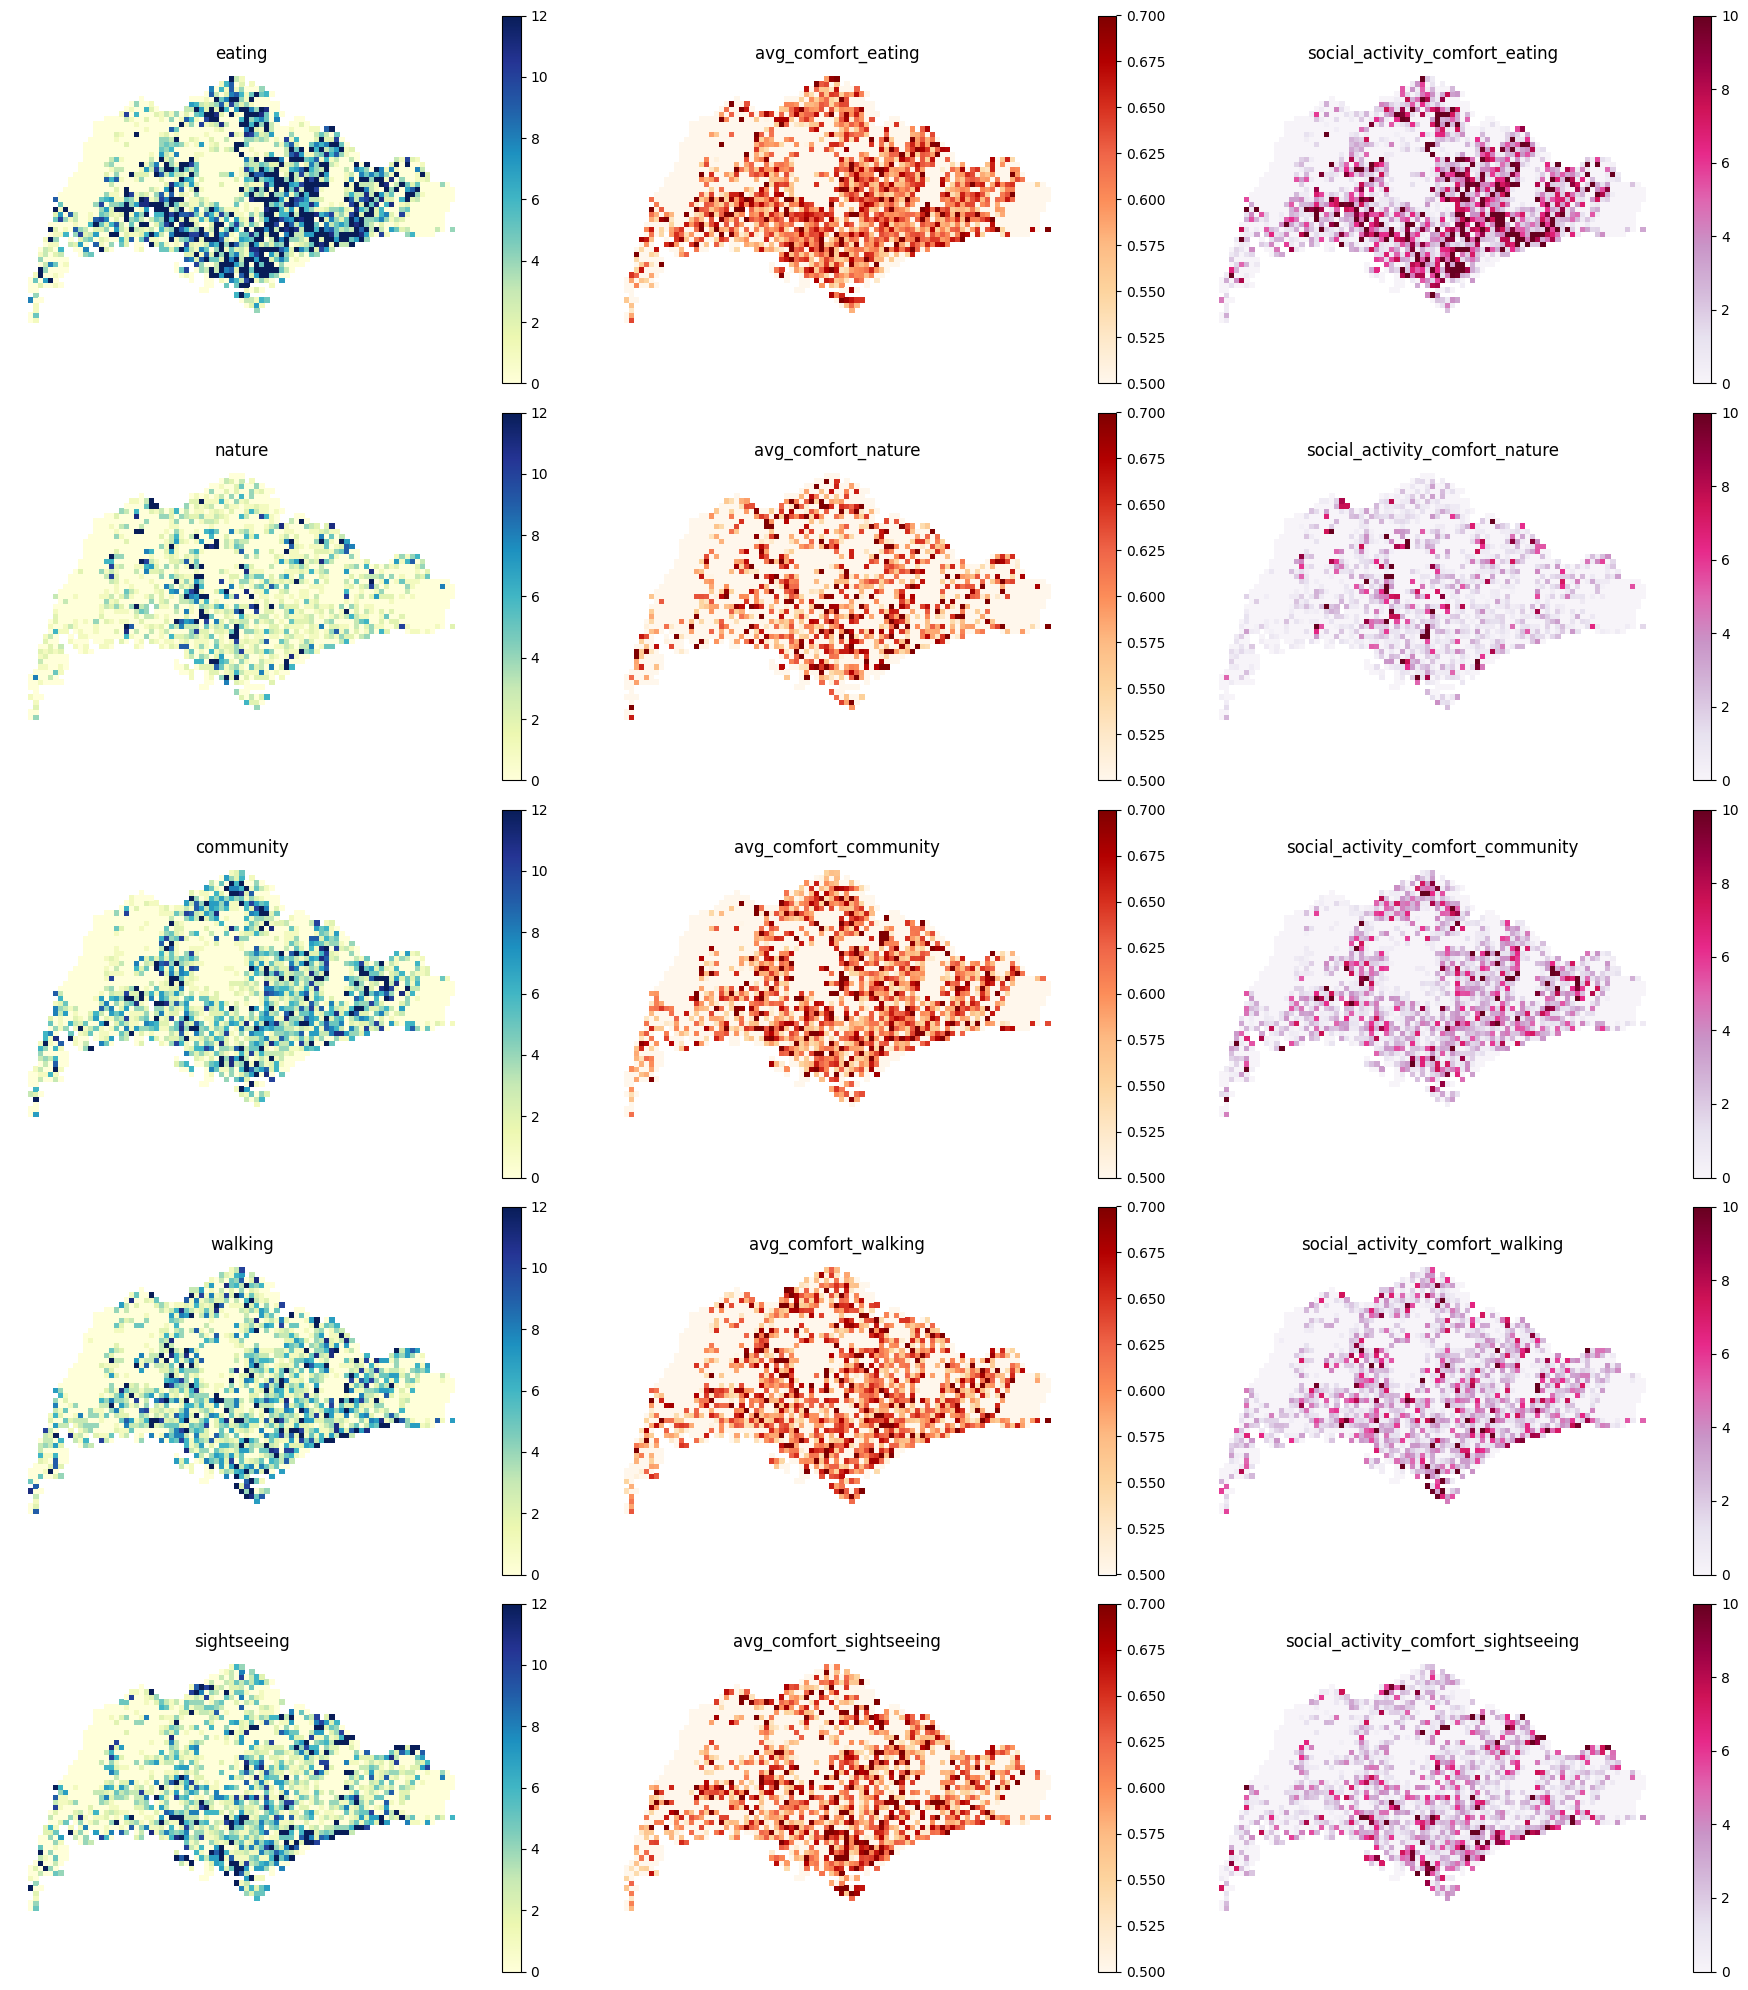

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

category_pairs = [
    ("eating", "avg_comfort_eating", "social_activity_comfort_eating"),
    ("nature", "avg_comfort_nature", "social_activity_comfort_nature"),
    ("community", "avg_comfort_community", "social_activity_comfort_community"),
    ("walking", "avg_comfort_walking", "social_activity_comfort_walking"),
    ("sightseeing", "avg_comfort_sightseeing", "social_activity_comfort_sightseeing"),
]

n_rows = len(category_pairs)
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))

if n_rows == 1:
    axes = [axes]

for i, (cat_col, score_col, comfort_col) in enumerate(category_pairs):
    ax_left = axes[i][0]
    ax_mid = axes[i][1]
    ax_right = axes[i][2]

    if cat_col not in gdf_merged.columns:
        ax_left.text(0.5, 0.5, f"Missing column: {cat_col}", ha="center", va="center")
        ax_left.set_axis_off()
    else:
        gdf_merged.plot(
            column=cat_col,
            cmap="YlGnBu",
            linewidth=0,
            legend=True,
            ax=ax_left,
            vmin=0,
            vmax=12,
            markersize=16,
            marker="s",
            missing_kwds={"color": "lightgrey", "label": "No data"},
        )
        ax_left.set_title(f"{cat_col}")
        ax_left.set_axis_off()

    if score_col not in gdf_merged.columns:
        ax_mid.text(0.5, 0.5, f"Missing column: {score_col}", ha="center", va="center")
        ax_mid.set_axis_off()
    else:
        gdf_merged.plot(
            column=score_col,
            cmap="OrRd",
            linewidth=0,
            legend=True,
            ax=ax_mid,
            vmin=0.5,
            vmax=0.7,
            markersize=16,
            marker="s",
            missing_kwds={"color": "lightgrey", "label": "No data"},
        )
        ax_mid.set_title(f"{score_col}")
        ax_mid.set_axis_off()

    if comfort_col not in gdf_merged.columns:
        ax_right.text(0.5, 0.5, f"Missing column: {comfort_col}", ha="center", va="center")
        ax_right.set_axis_off()
    else:
        vmax = float(gdf_merged[comfort_col].max()) if len(gdf_merged) > 0 else 1.0
        vmax = max(vmax, 1e-9)
        gdf_merged.plot(
            column=comfort_col,
            cmap="PuRd",
            linewidth=0,
            legend=True,
            ax=ax_right,
            vmin=0,
            vmax=10,
            markersize=16,
            marker="s",
            missing_kwds={"color": "lightgrey", "label": "No data"},
        )
        ax_right.set_title(f"{comfort_col}")
        ax_right.set_axis_off()

plt.tight_layout()
plt.show()
